In [17]:
!kaggle competitions download -c bike-sharing-demand
!unzip -o bike-sharing-demand.zip

100%|████████████████████████████████████████| 189k/189k [00:04<00:00, 46.5kB/s]

Archive:  bike-sharing-demand.zip
  inflating: sampleSubmission.csv    
  inflating: test.csv                
  inflating: train.csv               


In [43]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [45]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [47]:
train.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [49]:
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])

train['hour'] = train['datetime'].dt.hour
train['day'] = train['datetime'].dt.day
train['month'] = train['datetime'].dt.month

test['hour'] = test['datetime'].dt.hour
test['day'] = test['datetime'].dt.day
test['month'] = test['datetime'].dt.month

train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,day,month
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,1,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,1,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,1,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,1,1


In [51]:
from autogluon.tabular import TabularPredictor

train_data = train.drop(['casual', 'registered'], axis=1)

predictor = TabularPredictor(label="count", problem_type="regression").fit(
    train_data, 
    time_limit=600, 
    presets='best_quality'
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260415_001937"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.11.5
Operating System:   Darwin
Platform Machine:   x86_64
Platform Version:   Darwin Kernel Version 25.4.0: Thu Mar 19 19:33:09 PDT 2026; root:xnu-12377.101.15~1/RELEASE_ARM64_T8112
CPU Count:          8
Memory Avail:       0.62 GB / 8.00 GB (7.8%)
Disk Space Avail:   30.93 GB / 228.27 GB (13.6%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as 

(_ray_fit pid=8569) [1000]	valid_set's rmse: 35.9432
(_ray_fit pid=8566) [9000]	valid_set's rmse: 35.459 [repeated 54x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)


(_dystack pid=8529) 	-35.4596	 = Validation score   (-root_mean_squared_error)
(_dystack pid=8529) 	16.94s	 = Training   runtime
(_dystack pid=8529) 	9.0s	 = Validation runtime
(_dystack pid=8529) Fitting model: LightGBM_BAG_L1 ... Training model for up to 3.65s of the 44.99s of remaining time.
(_dystack pid=8529) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=1.31%)


(_ray_fit pid=8586) [1000]	valid_set's rmse: 36.5062 [repeated 6x across cluster]


(_ray_fit pid=8585) 	Ran out of time, early stopping on iteration 5549. Best iteration is:
(_ray_fit pid=8585) 	[5170]	valid_set's rmse: 35.5652
(_dystack pid=8529) 	-34.4061	 = Validation score   (-root_mean_squared_error)
(_dystack pid=8529) 	4.58s	 = Training   runtime
(_dystack pid=8529) 	1.8s	 = Validation runtime
(_dystack pid=8529) Fitting model: WeightedEnsemble_L2 ... Training model for up to 123.96s of the 35.70s of remaining time.
(_dystack pid=8529) 	Ensemble Weights: {'LightGBM_BAG_L1': 0.588, 'LightGBMXT_BAG_L1': 0.412}
(_dystack pid=8529) 	-33.3696	 = Validation score   (-root_mean_squared_error)
(_dystack pid=8529) 	0.01s	 = Training   runtime
(_dystack pid=8529) 	0.0s	 = Validation runtime
(_dystack pid=8529) Fitting 106 L2 models, fit_strategy="sequential" ...
(_dystack pid=8529) Fitting model: LightGBMXT_BAG_L2 ... Training model for up to 35.69s of the 35.67s of remaining time.
(_dystack pid=8529) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFol

In [53]:
# Predict the results for the test file
predictions = predictor.predict(test)

# Display the first 5 predictions
print("Model predictions for the first 5 hours of the test file:")
print(predictions.head())

Model predictions for the first 5 hours of the test file:
0    13.133541
1     1.796584
2     0.514791
3     1.821554
4     1.845760
Name: count, dtype: float32


In [65]:
predictor.leaderboard(silent=False)

                     model  score_val              eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0      WeightedEnsemble_L3 -31.627843  root_mean_squared_error      18.711279  338.031067                0.000483           0.026928            3       True         19
1      WeightedEnsemble_L2 -31.761220  root_mean_squared_error      17.079954  242.629452                0.000418           0.015925            2       True          9
2          CatBoost_BAG_L2 -32.078111  root_mean_squared_error      18.011871  273.241673                0.025860          26.304849            2       True         13
3     CatBoost_r177_BAG_L2 -32.207965  root_mean_squared_error      18.012850  272.873899                0.026839          25.937075            2       True         18
4     ExtraTreesMSE_BAG_L2 -32.286667  root_mean_squared_error      18.136558  247.874826                0.150547           0.938002            2       True    

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,-31.627843,root_mean_squared_error,18.711279,338.031067,0.000483,0.026928,3,True,19
1,WeightedEnsemble_L2,-31.761220,root_mean_squared_error,17.079954,242.629452,0.000418,0.015925,2,True,9
2,CatBoost_BAG_L2,-32.078111,root_mean_squared_error,18.011871,273.241673,0.025860,26.304849,2,True,13
3,CatBoost_r177_BAG_L2,-32.207965,root_mean_squared_error,18.012850,272.873899,0.026839,25.937075,2,True,18
4,ExtraTreesMSE_BAG_L2,-32.286667,root_mean_squared_error,18.136558,247.874826,0.150547,0.938002,2,True,14
5,XGBoost_BAG_L2,-32.389696,root_mean_squared_error,18.054591,248.583109,0.068580,1.646285,2,True,15
6,LightGBM_BAG_L2,-32.393599,root_mean_squared_error,18.069300,248.843393,0.083288,1.906569,2,True,11
7,RandomForestMSE_BAG_L2,-32.671460,root_mean_squared_error,18.113840,250.801686,0.127829,3.864862,2,True,12
8,LightGBMXT_BAG_L2,-32.709595,root_mean_squared_error,18.271609,249.159804,0.285598,2.222980,2,True,10
9,NeuralNetTorch_BAG_L2,-32.760551,root_mean_squared_error,18.311142,279.313066,0.325131,32.376242,2,True,16


In [61]:
import pandas as pd

submission = pd.read_csv("sampleSubmission.csv")

submission["count"] = predictions

submission.loc[submission["count"] < 0, "count"] = 0
submission.to_csv("submission.csv", index=False)

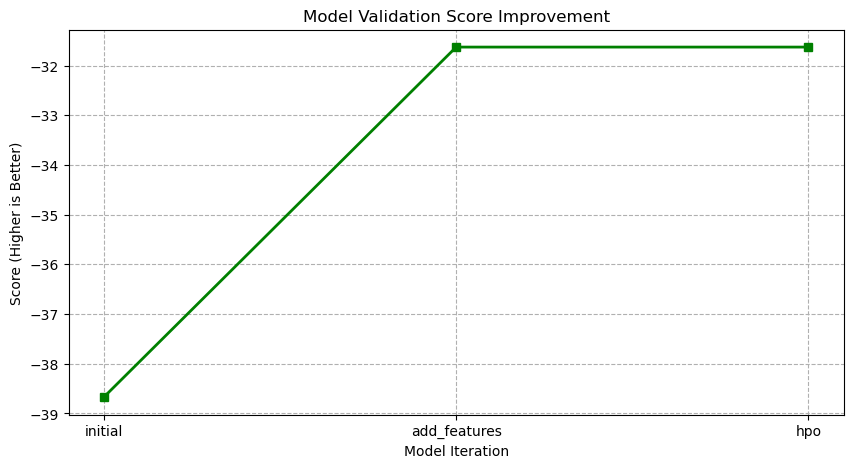

In [67]:
import matplotlib.pyplot as plt
import pandas as pd

validation_data = {
    "model": ["initial", "add_features", "hpo"],
    "score": [-38.674463, -31.627843, -31.627843] 
}

df_val = pd.DataFrame(validation_data)

plt.figure(figsize=(10, 5))
plt.plot(df_val["model"], df_val["score"], marker='s', color='green', linewidth=2)

plt.title("Model Validation Score Improvement")
plt.xlabel("Model Iteration")
plt.ylabel("Score (Higher is Better)")
plt.grid(True, linestyle='--')
plt.show()

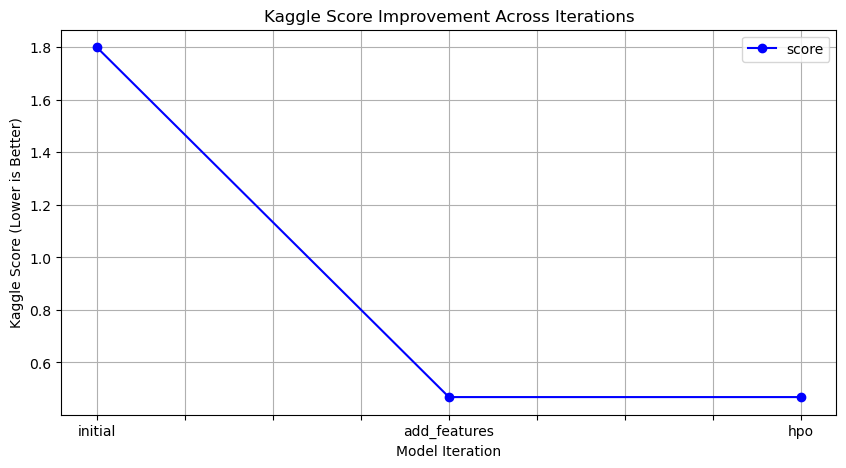

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

report_data = {
    "model": ["initial", "add_features", "hpo"],
    "score": [1.8, 0.46787, 0.46787] # 
}

df_report = pd.DataFrame(report_data)

df_report.plot(x="model", y="score", kind="line", marker="o", figsize=(10, 5), color='blue')

plt.title("Kaggle Score Improvement Across Iterations")
plt.xlabel("Model Iteration")
plt.ylabel("Kaggle Score (Lower is Better)")
plt.grid(True)
plt.show()